# Reading data
Read the train.csv file as a pandas dataframe.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
titanictrain = pd.read_csv("data/train.csv")
titanictrain

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Indexing
1. Create a function that returns the name of a passenger given their PassengerId.
2. Create a function that returns the PassengerId of a passenger given their Name.
3. Print a message with the ID of passenger **Montvila, Rev. Juozas** with the following format: 'The ID pf passenger Montvila, Rev. Juozas is ##'
4. Print a message with the name of the passenger with ID **42** with the following format: 'The passenger with ID 42 is X'

5. Print all information about the oldest passenger.

In [4]:
titanictrain[titanictrain.PassengerId == 1].Name

0    Braund, Mr. Owen Harris
Name: Name, dtype: object

In [5]:
def id_to_name(df:pd.DataFrame, id:int) -> str:
    """_summary_

    Args:
        df (pd.DataFrame): _description_
        id (int): _description_

    Returns:
        str: _description_
    """
    pasajero = df[df["PassengerId"] == id]
    nombre = pasajero["Name"]
    return print(f"El pasajero que tiene el id: {id} se llama: {nombre}")

id_to_name(titanictrain,3)


El pasajero que tiene el id: 3 se llama: 2    Heikkinen, Miss. Laina
Name: Name, dtype: object


In [6]:
def name_to_id(df:pd.DataFrame,nombre:str) -> int:
    """_summary_

    Args:
        df (pd.DataFrame): _description_
        nombre (str): _description_

    Returns:
        int: _description_
    """
    id = df[df["Name"] == nombre]
    numero = id["PassengerId"]
    return print(f"El pasajero {nombre} tiene el id: {numero}")
name_to_id(titanictrain,"Behr, Mr. Karl Howell")

El pasajero Behr, Mr. Karl Howell tiene el id: 889    890
Name: PassengerId, dtype: int64


In [7]:
def mas_viejo(df: pd.DataFrame) -> str:
    """_summary_

    Args:
        df (pd.DataFrame): _description_

    Returns:
        str: _description_
    """
    viejo_idx = df["Age"].idxmax()  # Encuentra el índice del pasajero más viejo
    viejo = df.loc[viejo_idx]  # Obtiene toda la fila del pasajero más viejo

    return print(f"El pasajero de mayor edad es {viejo['Name']} con {viejo['Age']} años")

mas_viejo(titanictrain)



El pasajero de mayor edad es Barkworth, Mr. Algernon Henry Wilson con 80.0 años


# Subseting
We are asked to share data for analysis by a third party. Since our dataset contains personal details, we only want to share with them the following information: ticket classes, fares and port of embarkation. We are asked to deliver a sample of the first 100 rows of this dataset.

6. Create and save the new dataset in **data/port_fares.csv**.

In [8]:
def clasificado(df: pd.DataFrame) -> pd.DataFrame:
    """_summary_

    Args:
        df (pd.DataFrame): _description_

    Returns:
        pd.DataFrame: _description_
    """
    nuevo_df = df[["Pclass", "Fare", "Embarked"]].head(100)  # Selecciona las columnas y las primeras 100 filas
    return nuevo_df

nuevo_dataset = clasificado(titanictrain)

# Guardar el resultado en un archivo CSV
nuevo_dataset.to_csv("data/port_fares.csv", index=False)
nuevo_dataset



,Pclass,Fare,Embarked
0,3,7.2500,S
1,1,71.2833,C
2,3,7.9250,S
3,1,53.1000,S
4,3,8.0500,S
...,...,...,...
95,3,8.0500,S
96,1,34.6542,C
97,1,63.3583,C
98,2,23.0000,S


# Counting
7. We want to know if there were any survivors over the age of 60, print all of their information.
8. How many people over 60 survived?
9. What percentage of people over 60 survived?

In [9]:
def sobrevivientes60(df:pd.DataFrame) -> float:
    """_summary_

    Args:
        df (pd.DataFrame): _description_

    Returns:
        float: _description_
    """
    mayores_60 = df[df["Age"] > 60]
    sobrevivientes = mayores_60[mayores_60["Survived"] == 1]

    print("Información de los sobrevivientes mayores de 60 años:")
    print(sobrevivientes)

    num_sobrevivientes = sobrevivientes.shape[0] #obtiene el número de filas del DataFrame
    print(f"\nNúmero de sobrevivientes mayores de 60 años: {num_sobrevivientes}")

    total_mayores_60 = mayores_60.shape[0]
    
    if total_mayores_60 > 0:
        porcentaje = (num_sobrevivientes / total_mayores_60) * 100
    else:
        porcentaje = 0  # Evitar división por cero si no hay mayores de 60

    print(f"Porcentaje de sobrevivientes mayores de 60 años: {porcentaje:.2f}%")

sobrevivientes60(titanictrain)


Información de los sobrevivientes mayores de 60 años:
     PassengerId  Survived  Pclass                                       Name  \
275          276         1       1          Andrews, Miss. Kornelia Theodosia   
483          484         1       3                     Turkula, Mrs. (Hedwig)   
570          571         1       2                         Harris, Mr. George   
630          631         1       1       Barkworth, Mr. Algernon Henry Wilson   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch       Ticket     Fare Cabin Embarked  
275  female  63.0      1      0        13502  77.9583    D7        S  
483  female  63.0      0      0         4134   9.5875   NaN        S  
570    male  62.0      0      0  S.W./PP 752  10.5000   NaN        S  
630    male  80.0      0      0        27042  30.0000   A23        S  
829  female  62.0      0      0       113572  80.0000   B28      NaN  

Número de sobrevivientes mayores

# Women and children first?
10. Find out if women and children were more likely to survive.

In [10]:
def mujeresvsniños(df : pd.DataFrame) -> str:
    """_summary_

    Returns:
        _type_: _description_
    """
    MujeresyNinos = df[(df["Sex"] == "female") | (df["Age"] < 18)]
    hombres = df[(df["Sex"] == "male") & (df["Age"] >= 18)]
    sobrevivientesMuyNi = MujeresyNinos[MujeresyNinos["Survived"] == 1]
    sobrevivientesHombres = hombres[hombres["Survived"] == 1]
    num_sobrevivientes_MuyNi = sobrevivientesMuyNi.shape[0]
    num_sobrevivientes_Hombres = sobrevivientesHombres.shape[0]
    total_MujeresyNinos = MujeresyNinos.shape[0]
    total_Hombres = hombres.shape[0]
    porcentaje_MuyNi = round((num_sobrevivientes_MuyNi / total_MujeresyNinos) * 100,2)
    porcetaje_Hombres = round((num_sobrevivientes_Hombres / total_Hombres) * 100,2)
    if porcentaje_MuyNi == porcetaje_Hombres:
        return print(f"Es igual de probable que sobrevia un niño a una mujer, porcentaje de sobrevivientes = {porcetaje_Hombres}")
    elif porcentaje_MuyNi > porcetaje_Hombres:
        return print(f"Sobrevivieron mas mujeres y niños con un {porcentaje_MuyNi}% de sobrevientes, que hombres con {porcetaje_Hombres}%, tienes más probabilidades de sobrevivir sinedo Mujer o niño")
    else:
         return print(f"Sobrevivieron mas Hombres con un {porcetaje_Hombres}% de sobrevientes, que mujeres y niños con {porcentaje_MuyNi}%, , tienes más probabilidades de sobrevivir sinedo Hombre")

mujeresvsniños(titanictrain)


Sobrevivieron mas mujeres y niños con un 68.82% de sobrevientes, que hombres con 17.72%, tienes más probabilidades de sobrevivir sinedo Mujer o niño


11. Write a function that returns the percentage of people that survived from a subset given as a boolean Pandas series.

In [11]:
def porcentaje(subset: pd.Series) -> float:
    """
    Calculates the percentage of survivors in a given boolean Pandas Series.

    Args:
        subset (pd.Series): A boolean Series where True represents survival.

    Returns:
        float: The percentage of survivors.
    """
    num_sobrevivientes = subset.sum()  
    total = subset.shape[0]
    
    if total > 0:
        porcentash = round((num_sobrevivientes / total) * 100, 2)
        return f"Porcentaje de sobrevivientes = {porcentash}%"
    else:
        return "Esta maaal"
porcentaje(titanictrain["Survived"] == 1)

'Porcentaje de sobrevivientes = 38.38%'

# Summarizing

12. What is the median age of the passengers?
13. How many passengers embarked from each port?

In [12]:
def mediana_edad(df: pd.DataFrame) -> float:
    """Calcula la mediana de la edad de los pasajeros.

    Args:
        df (pd.DataFrame): DataFrame que contiene la información de los pasajeros.

    Returns:
        float: Mediana de la edad de los pasajeros.
    """
    mediana = df["Age"].median()
    print(f"La mediana de la edad de los pasajeros es: {mediana}")
    return mediana

# Llamada a la función
tablinha = mediana_edad(titanictrain)
tablinha

La mediana de la edad de los pasajeros es: 28.0


np.float64(28.0)

In [13]:
def pasajeros_por_puerto(df: pd.DataFrame) -> pd.Series:
    """Cuenta cuántos pasajeros embarcaron desde cada puerto.

    Args:
        df (pd.DataFrame): DataFrame que contiene la información de los pasajeros.

    Returns:
        pd.Series: Una serie con el número de pasajeros por puerto de embarque.
    """
    conteo_por_puerto = df["Embarked"].value_counts()
    print("Número de pasajeros que embarcaron desde cada puerto:")
    print(conteo_por_puerto)
    return conteo_por_puerto

# Llamada a la función
pasajeros_por_puerto(titanictrain)

Número de pasajeros que embarcaron desde cada puerto:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

14. Generate two hypotheses about how does the survival rate differ among groups of passengers. Write your code to explore both hypotheses.

Hipótesis 1: La tasa de supervivencia es mayor en mujeres que en hombres.

Hipótesis 2: La tasa de supervivencia es mayor en pasajeros de primera clase que en pasajeros de segunda o tercera clase.

Tasa de supervivencia por sexo:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


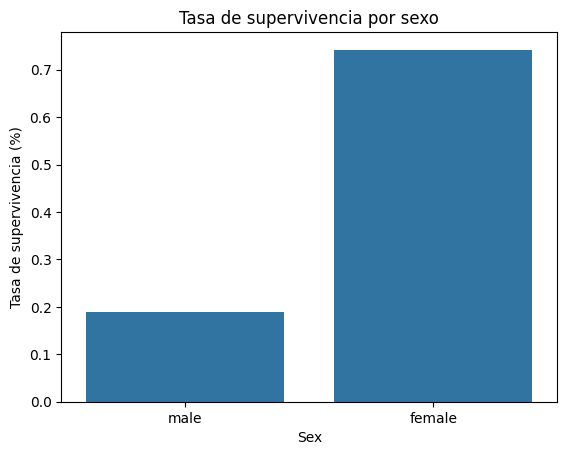

In [ ]:
def explorar_hipotesis_sexo(df: pd.DataFrame):
    """Explora la hipótesis de que la tasa de supervivencia es mayor en mujeres que en hombres.

    Args:
        df (pd.DataFrame): DataFrame que contiene la información de los pasajeros.
    """
    # Agrupar por sexo y calcular la tasa de supervivencia
    tasa_supervivencia_sexo = df.groupby("Sex")["Survived"].mean() * 100

    print("Tasa de supervivencia por sexo:")
    print(tasa_supervivencia_sexo)

    sns.barplot(x="Sex", y="Survived", data=df, errorbar=None)
    plt.title("Tasa de supervivencia por sexo")
    plt.ylabel("Tasa de supervivencia (%)")
    plt.show()

# Llamada a la función
explorar_hipotesis_sexo(titanictrain)

Tasa de supervivencia por clase:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


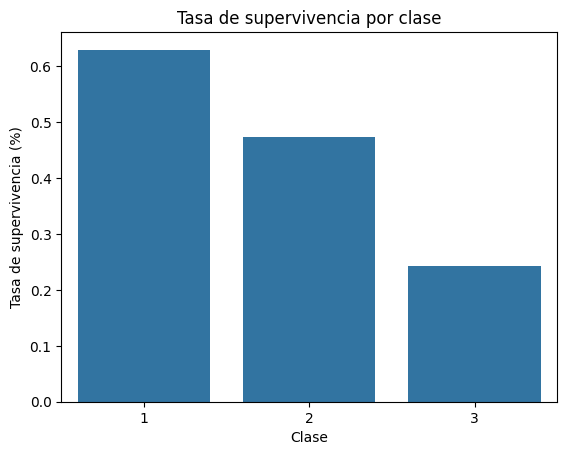

In [19]:
def explorar_hipotesis_clase(df: pd.DataFrame):
    """Explora la hipótesis de que la tasa de supervivencia es mayor en pasajeros de primera clase.

    Args:
        df (pd.DataFrame): DataFrame que contiene la información de los pasajeros.
    """
    # Agrupar por clase y calcular la tasa de supervivencia
    tasa_supervivencia_clase = df.groupby("Pclass")["Survived"].mean() * 100

    print("Tasa de supervivencia por clase:")
    print(tasa_supervivencia_clase)

    # Visualización
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.barplot(x="Pclass", y="Survived", data=df, errorbar=None)
    plt.title("Tasa de supervivencia por clase")
    plt.ylabel("Tasa de supervivencia (%)")
    plt.xlabel("Clase")
    plt.show()

# Llamada a la función
explorar_hipotesis_clase(titanictrain)

In [16]:
import numpy as np

np.arange(10) 

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [17]:
import time

start = time.time()

total = 0

for i in np.arange(10000000):
    total = i + total

print(total)
end = time.time()

print(end-start)

49999995000000
1.8432228565216064


In [18]:
start = time.time()

print(np.sum(np.arange(10000000)))

end = time.time()

print(end-start)

49999995000000
0.028931617736816406
